# Analyzing river profiles in the Coastal Cordillera around the outlet of the Mataquito River

## Overview

**Purpose**: Analyze chi-elevation (χ-z) profiles for coastal streams near the Mataquito River outlet to characterize knickpoint migration and drainage reorganization in the Coastal Cordillera.

**Inputs**:
- `dem_utm30m.tif`, `fd_utm30m`, `area_utm30m` — external DEM data (not in repository)
- Outlet coordinates (UTM) for 6 coastal streams: Estero Curepto, Huenchullami River, Estero Los Cuervos, Estero Vichuquen, Estero San Pedro de Alcantara, Estero Paredones

**Outputs**:
- Chi vs. elevation plots for each coastal stream, with reference elevations marked

**Note**: Requires the external `TopoAnalysis` package and DEM data. The DEM file path must be configured in the `EXTERNAL DATA PATHS` cell below.

In [1]:
from TopoAnalysis import dem as d
import matplotlib.pylab as plt
from TopoAnalysis.plotting import plot_recursive_upstream_profiles
import numpy as np
import os
import pandas as pd

In [2]:
# Setting directory for files
# ── EXTERNAL DATA PATHS ──────────────────────────────────────────────
# These files are not included in the repository. Update the path below
# to point to your local DEM data directory containing area_utm30m,
# fd_utm30m, and dem_utm30m.tif.
DEM_DATA_DIR = '../data/dem'

new_directory_path = DEM_DATA_DIR  
os.chdir(new_directory_path)
print("New working directory:", os.getcwd())

New working directory: /Users/Glong1/Desktop/Andes/Chapter_1_Manuscript/MataquitoWatershedAnalysis/Mataquito/data/dem


In [3]:
area = d.Area.load('area_utm30m')
print('area loaded')
fd = d.FlowDirectionD8.load('fd_utm30m')
print('fd loaded')
elevation = d.Elevation.load('dem_utm30m.tif')
print('elevation loaded')

area loaded
fd loaded
elevation loaded


In [ ]:
# Define your single outlet point
outlets = [(220105, 6117333),
           (207214, 6108725),
           (211126, 6118233),
           (223394, 6139757),
           (220209, 6157379),
           (221083, 6162719),
           (314210.84669270925223827,6096047.77876485418528318),
           (333230.86321506532840431, 6125063.64466395881026983)
]
samples = [('Estero Curepto'),
           ('Huenchullami River'),
           ('Estero Los Cuervos'),
           ('Estero Vichuquen'),
           ('Estero San Pedro de Alcantara'),
           ('Estero Paredones'),
           ('CT-1'),
           ('CT-7')
]

for i, (outlet, sample) in enumerate(zip(outlets, samples)):
    chi_single = d.Chi(flow_direction=fd, area=area, theta=0.5, Ao=1, outlets=[outlet])
    
    chi_data = chi_single._griddata[chi_single._griddata > 0]
    elev_data = elevation._griddata[chi_single._griddata > 0]
    area_data = area._griddata[chi_single._griddata > 0]
    
    # Mask out areas less than 1 km^2
    mask_out = area_data >= 1e6  # 1 km^2 in m^2
    
    plt.figure(figsize=(18, 6))
    plt.scatter(chi_data[mask_out], elev_data[mask_out], s=1, alpha=0.5)
    #plt.axhline(y=117, color='red', linestyle='--', linewidth=1)
    #plt.axhline(y=175, color='red', linestyle='--', linewidth=1)
    plt.xlabel('$\\chi$(m)')
    plt.ylabel('Elevation(m)')
    plt.title(f'$\\chi$ vs Elevation - {sample}')
    #plt.savefig(f'Figures/chi_elevation_plot_{sample}.png', bbox_inches='tight', pad_inches=0.1)  # Unique filename for each
    plt.show()

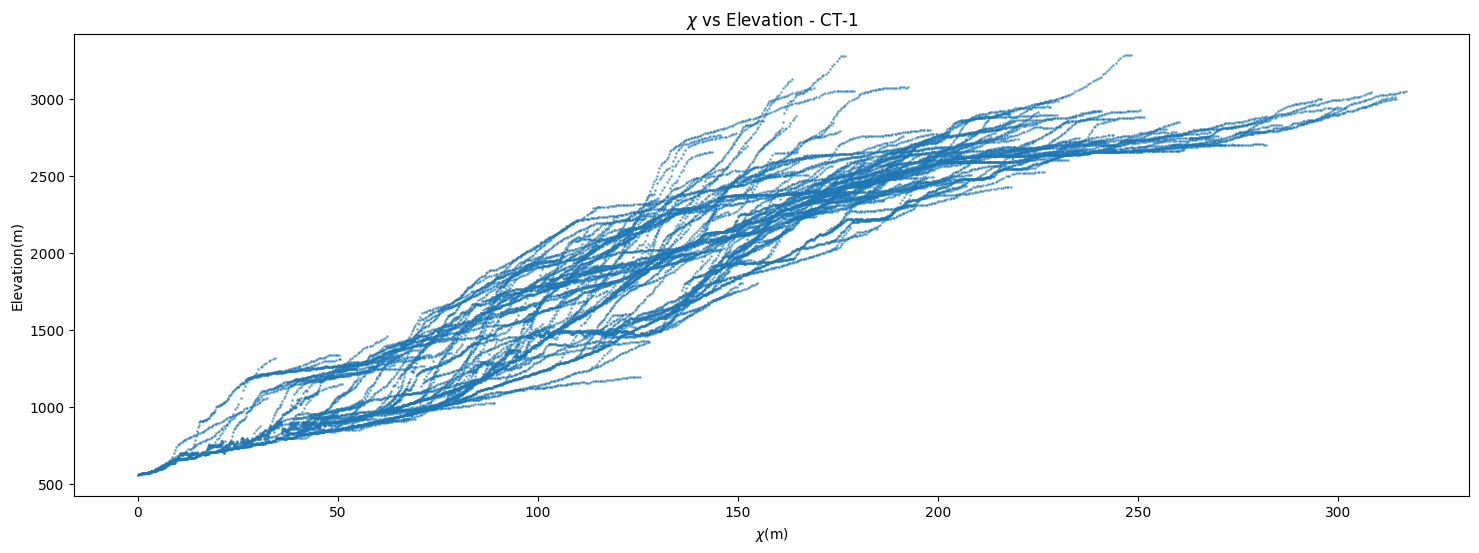

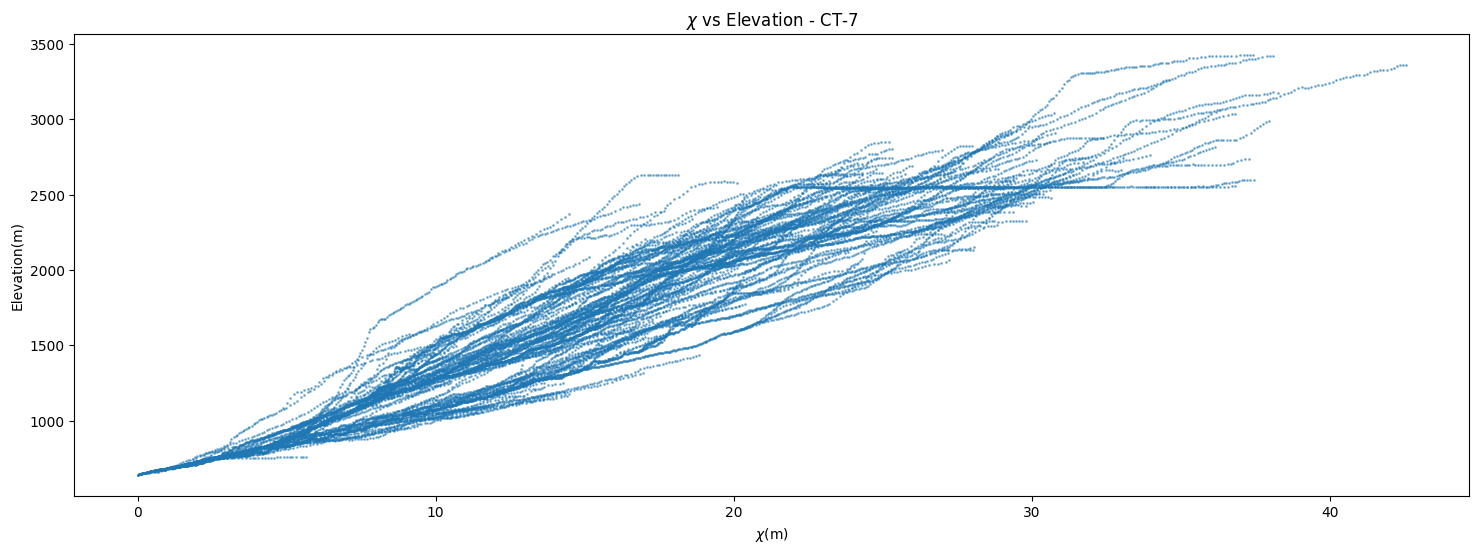

In [8]:
# Define your single outlet point
outlets = [(314210.84669270925223827,6096047.77876485418528318),
           (333230.86321506532840431, 6125063.64466395881026983)
]
samples = [('CT-1'),
           ('CT-7')
]

best_mn = {'CT-1': 0.3, 'CT-7': 0.4}

for i, (outlet, sample) in enumerate(zip(outlets, samples)):
    chi_single = d.Chi(flow_direction=fd, area=area, theta=best_mn[sample], Ao=1, outlets=[outlet])
    
    chi_data = chi_single._griddata[chi_single._griddata > 0]
    elev_data = elevation._griddata[chi_single._griddata > 0]
    area_data = area._griddata[chi_single._griddata > 0]
    
    # Mask out areas less than 1 km^2
    mask_out = area_data >= 1e6  # 1 km^2 in m^2
    
    plt.figure(figsize=(18, 6))
    plt.scatter(chi_data[mask_out], elev_data[mask_out], s=1, alpha=0.5)
    plt.xlabel('$\\chi$(m)')
    plt.ylabel('Elevation(m)')
    plt.title(f'$\\chi$ vs Elevation - {sample}')
    #plt.savefig(f'Figures/chi_elevation_plot_{sample}.png', bbox_inches='tight', pad_inches=0.1)  # Unique filename for each
    plt.show()

1/38 | CT-1 | m/n=0.10 | step=22.8s | est. remaining=14.1 min
2/38 | CT-1 | m/n=0.15 | step=22.5s | est. remaining=13.5 min
3/38 | CT-1 | m/n=0.20 | step=22.8s | est. remaining=13.3 min
4/38 | CT-1 | m/n=0.25 | step=22.6s | est. remaining=12.8 min
5/38 | CT-1 | m/n=0.30 | step=22.5s | est. remaining=12.4 min
6/38 | CT-1 | m/n=0.35 | step=22.6s | est. remaining=12.0 min
7/38 | CT-1 | m/n=0.40 | step=22.6s | est. remaining=11.7 min
8/38 | CT-1 | m/n=0.45 | step=22.6s | est. remaining=11.3 min
9/38 | CT-1 | m/n=0.50 | step=23.0s | est. remaining=11.1 min
10/38 | CT-1 | m/n=0.55 | step=22.6s | est. remaining=10.5 min
11/38 | CT-1 | m/n=0.60 | step=22.6s | est. remaining=10.2 min
12/38 | CT-1 | m/n=0.65 | step=22.6s | est. remaining=9.8 min
13/38 | CT-1 | m/n=0.70 | step=22.7s | est. remaining=9.4 min
14/38 | CT-1 | m/n=0.75 | step=22.6s | est. remaining=9.1 min
15/38 | CT-1 | m/n=0.80 | step=22.7s | est. remaining=8.7 min
16/38 | CT-1 | m/n=0.85 | step=22.7s | est. remaining=8.3 min
17/38 

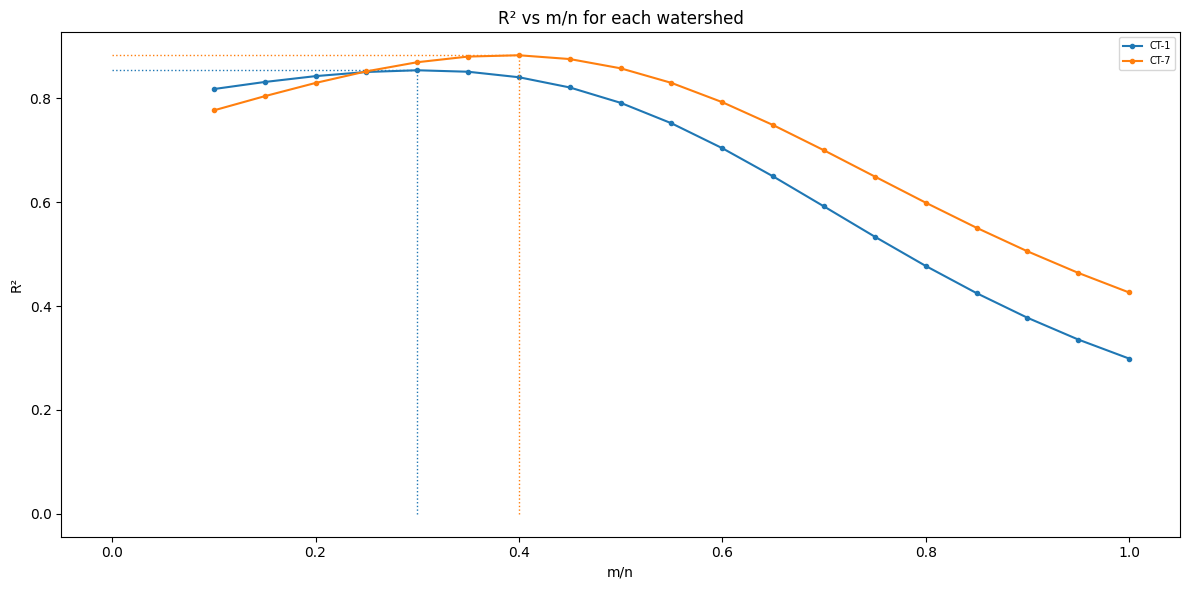

In [7]:
from scipy.stats import linregress
import time

mn_values = np.arange(0.1, 1.05, 0.05)
results = {sample: [] for sample in samples}
total = len(outlets) * len(mn_values)
count = 0

for i, (outlet, sample) in enumerate(zip(outlets, samples)):
    for mn in mn_values:
        start = time.time()
        chi_single = d.Chi(flow_direction=fd, area=area, theta=mn, Ao=1, outlets=[outlet])
        
        chi_data = chi_single._griddata[chi_single._griddata > 0]
        elev_data = elevation._griddata[chi_single._griddata > 0]
        area_data = area._griddata[chi_single._griddata > 0]
        
        mask_out = area_data >= 1e6
        
        slope, intercept, r, p, se = linregress(chi_data[mask_out], elev_data[mask_out])
        results[sample].append(r**2)
        
        count += 1
        elapsed = time.time() - start
        remaining = elapsed * (total - count)
        print(f'{count}/{total} | {sample} | m/n={mn:.2f} | step={elapsed:.1f}s | est. remaining={remaining/60:.1f} min')

plt.figure(figsize=(12, 6))
for sample in samples:
    r2 = results[sample]
    best_mn = mn_values[np.argmax(r2)]
    best_r2 = max(r2)
    p = plt.plot(mn_values, r2, label=sample, marker='o', markersize=3)
    color = p[0].get_color()
    plt.vlines(best_mn, 0, best_r2, colors=color, linestyles='dotted', linewidth=1)
    plt.hlines(best_r2, 0, best_mn, colors=color, linestyles='dotted', linewidth=1)

plt.xlabel('m/n')
plt.ylabel('R²')
plt.title('R² vs m/n for each watershed')
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()